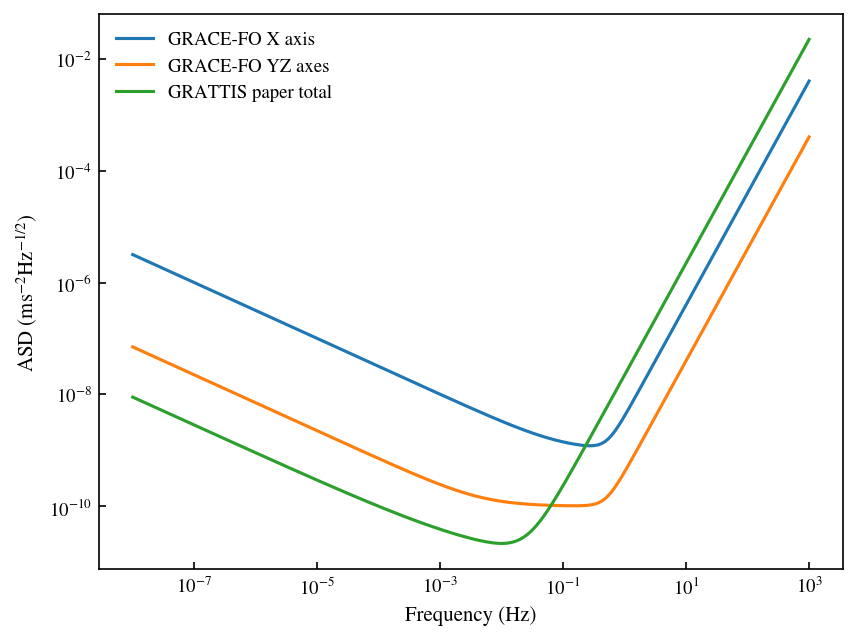

In [1]:
import numpy as np
import scipy.fft, scipy.signal, scipy.interpolate
from SpaceBalls.plotter import Plotter
import matplotlib.pyplot as plt


def a_noise_psd_grattis(f_vec):
    f_vec_abs = np.abs(f_vec)
    # noise sources:
    readout = 2/9*1e-7 * f_vec_abs**2
    actuation = 2*np.sqrt(2)*10**(-12.5) * f_vec_abs**(-0.5)
    actuation_stiffness = 1.05*1e-11 + 0 * f_vec_abs
    total_grattis = readout + actuation + actuation_stiffness

    return total_grattis

f_min = 1e-8
f_vec = np.logspace(np.log10(f_min), 3, 200) # Hz

# from that GRACE paper
sqrt_PSD_x = np.sqrt(1 + (f_vec/0.5)**4 + (0.1/f_vec)) * 1e-9
sqrt_PSD_yz = np.sqrt(1 + (f_vec/0.5)**4 + (0.005/f_vec)) * 1e-10

points_grattis = np.array([[1e-4, 1e-10],
                            [5e-4, 4e-11],
                            [1e-2, 1.7e-11],
                            [1.6e-2, 1.5e-11],
                            [2e-2, 1.7e-11],
                            [3e-2, 2.5e-11],
                            [1e-1, 2.5e-10],
                            [6.5e-1, 1e-8]])
f_vec_red = np.logspace(np.log10(points_grattis[0,0]), 
                        np.log10(points_grattis[-1,0]), 100)
# interp = scipy.interpolate.PchipInterpolator(points_grattis[:,0], 
#                                               points_grattis[:,1])
# sqrt_PSD_grattis = interp(f_vec_red)

total_grattis = a_noise_psd_grattis(f_vec)


plt.loglog(f_vec, sqrt_PSD_x, label='GRACE-FO X axis')
plt.loglog(f_vec, sqrt_PSD_yz, label='GRACE-FO YZ axes')
#plt.loglog(points_grattis[:,0], points_grattis[:,1], label='GRATTIS paper')
plt.loglog(f_vec, total_grattis, label='GRATTIS paper total')

plt.xlabel('Frequency (Hz)')
plt.ylabel('ASD (ms$^{-2}$Hz$^{-1/2}$)')
plt.legend()

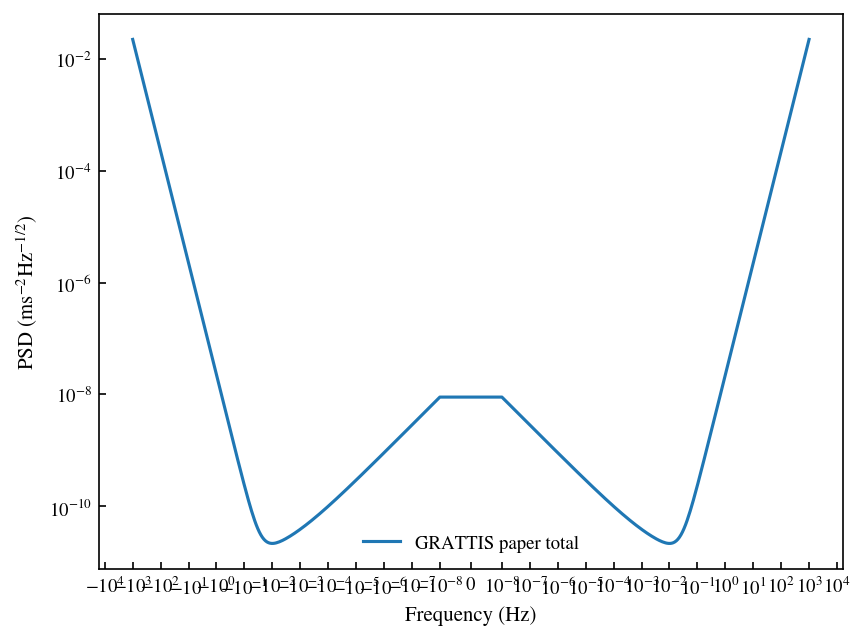

In [10]:
double_f_vec = np.concatenate((-np.flip(f_vec), f_vec))
double_total_grattis = np.concatenate((np.flip(total_grattis), total_grattis))

#plt.semilogy(f_vec, sqrt_PSD_x, label='GRACE-FO X axis')
#plt.semilogy(f_vec, sqrt_PSD_yz, label='GRACE-FO YZ axes')
plt.semilogy(double_f_vec, double_total_grattis, label='GRATTIS paper total')
plt.xscale('symlog', linthresh=1e-8)

plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (ms$^{-2}$Hz$^{-1/2}$)')
plt.legend()

/tmp/ipykernel_1056635/1299531950.py:11: RuntimeWarning: divide by zero encountered in power
  actuation = 2*np.sqrt(2)*10**(-12.5) * f_vec_abs**(-0.5)


/media/monte_share/conda_envs/dataproc/lib/python3.14/site-packages/IPython/core/events.py:96: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/media/monte_share/conda_envs/dataproc/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


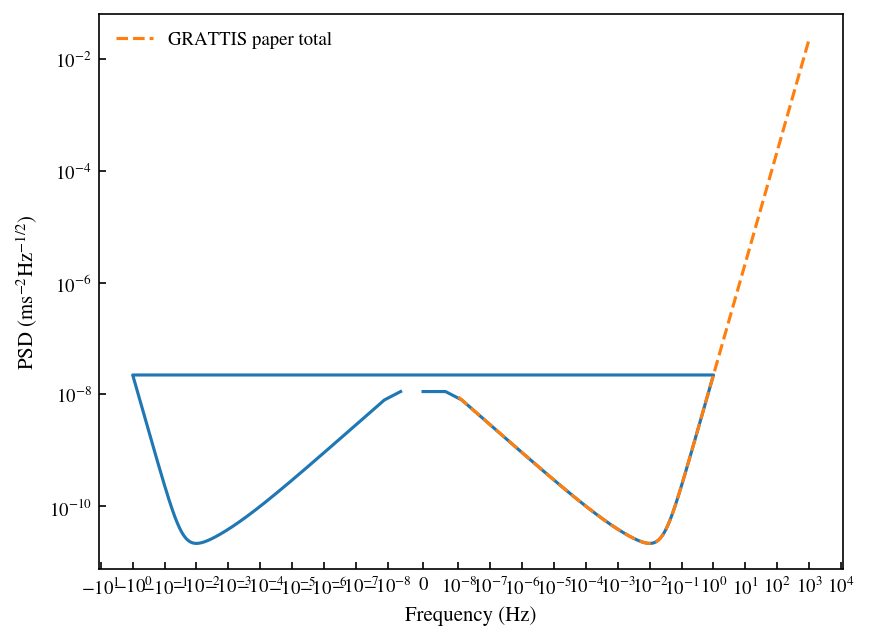

: 

In [ ]:
from SpaceBalls.utils import get_fft_spectrum

dt = 0.5
n_meas = int(5 * 365 * 24 * 60 * 60/dt)
t_vec = np.arange(0, n_meas*dt, dt)
T = t_vec[-1] - t_vec[0]
gaussian_noise = np.random.randn(n_meas)

#freqs, amplitude, power, psd = get_fft_spectrum(gaussian_noise, t_vec, one_sided=False)
freqs = scipy.fft.fftfreq(n_meas, dt)
fft = scipy.fft.fft(gaussian_noise)
sqrt_psd = fft / np.sqrt(T)

filter_at_noise_freqs = a_noise_psd_grattis(freqs)
filter_at_noise_freqs[0] = filter_at_noise_freqs[1] # set DC term to that of smallest freq.
#noise_spectrum = sqrt_psd * double_total_grattis

transfer_H = filter_at_noise_freqs / sqrt_psd
filtered_fft = fft * transfer_H

#plt.semilogy(double_f_vec, double_total_grattis, label='GRATTIS paper total')
#plt.semilogy(freqs, sqrt_psd)
#plt.semilogy(freqs, filter_sqrt_psd)

plt.semilogy(freqs, filter_at_noise_freqs)
plt.loglog(f_vec, total_grattis, label='GRATTIS paper total', linestyle='--')

plt.xscale('symlog', linthresh=1e-8)

plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (ms$^{-2}$Hz$^{-1/2}$)')
plt.legend()

In [7]:
# corrected spectral shaping of existing white noise
# (assumes a_noise_psd_grattis(freqs) returns ASD (m/s^2 / sqrt(Hz)); if it returns PSD, do np.sqrt(...))

dt = 0.5
n_meas = int(5 * 365 * 24 * 60 * 60 / dt)
t_vec = np.arange(0, n_meas*dt, dt)
N = n_meas
x = np.random.randn(N)  # or your gaussian_noise

# rfft domain (one-sided)
X = scipy.fft.rfft(x)
freqs = scipy.fft.rfftfreq(N, dt)
df = 1.0 / (N * dt)

# current one-sided PSD and ASD
power = (np.abs(X)**2) / (N**2)        # bin power
# convert to one-sided bin power (double positive bins except DC and Nyquist if present)
if N % 2 == 0:
    power[1:-1] *= 2.0
else:
    power[1:] *= 2.0
psd_current = power / df
asd_current = np.sqrt(psd_current)

# desired ASD from model (ensure it is defined on freqs)
asd_desired = a_noise_psd_grattis(freqs)  # if returns PSD: asd_desired = np.sqrt(a_noise_psd_grattis(freqs))
asd_desired[0] = asd_desired[1]

# avoid divide-by-zero at DC
H = asd_desired / asd_current # (asd_current + 1e-30)

# apply transfer (keeps original phases)
X_filtered = X * H

# inverse to time domain
filtered_noise = scipy.fft.irfft(X_filtered, n=N)


/tmp/ipykernel_1056635/1838191955.py:25: RuntimeWarning: divide by zero encountered in power
  actuation = 2*np.sqrt(2)*10**(-12.5) * f_vec_abs**(-0.5)


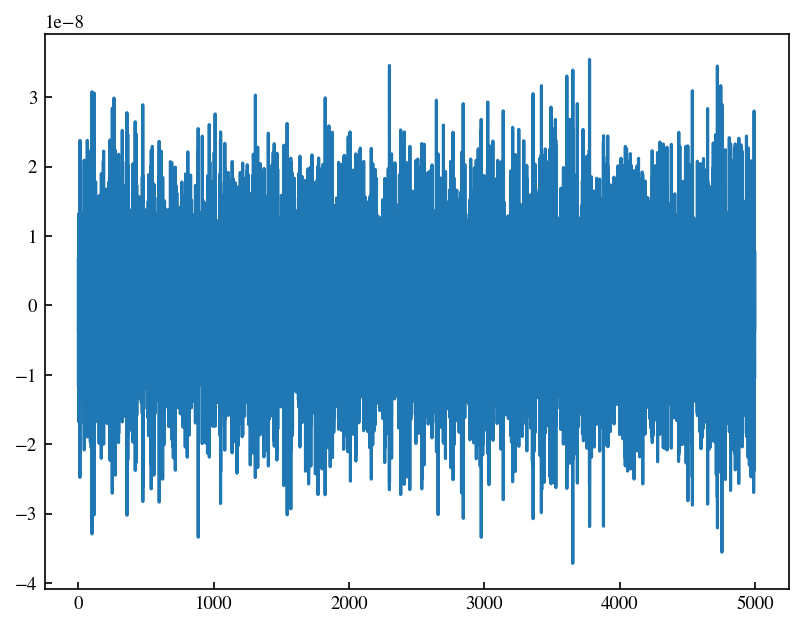

In [6]:
plt.plot(t_vec[:10000], filtered_noise[:10000])

In [ ]:
def compute_P(a,b,c,d,f):
    return a * np.sqrt(b + (f/c)**4 + d/f)

def dP_da(a,b,c,d,f):
    return compute_P(a,b,c,d,f) / a

def dP_db(a,b,c,d,f):
    return 1/2 * a * (b + (f/c)**4 + d/f)**(-0.5)

def dP_dc(a,b,c,d,f):
    return dP_db(a,b,c,d,f) * (-4 * f**4 / (c**3))

def dP_dd(a,b,c,d,f):
    return dP_db(a,b,c,d,f) * 1 / f